In [29]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
# ============================================================
# 2. PROJECT PATH
# ============================================================

import importlib
import src.data_pipeline

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

importlib.reload(src.data_pipeline)

from src.data_pipeline import ModelDatasetBuilder
from src.events import SimpleEventDetector

In [31]:
# ============================================================
# 3. DATABASE PATH
# ============================================================

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

print("DB exists:", db_path.exists())
print("DB path:", db_path)

builder = ModelDatasetBuilder(db_path)

DB exists: True
DB path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\data\thesis_database.db


In [38]:
# ============================================================
# 4. LOAD DATA
# ============================================================

df = builder.build_price_dataset(
    zones="NO1",
    start_date="2020-01-01",
    end_date="2020-12-31",
    add_time_features=True,
    lags=[1, 2, 24],
    target_horizon=1,
    # dropna=True Ignore rows with NaN values (due to lags)
)

df.head()

,price_id,zone_id,delivery_day,hour,price_value,year,month,day,day_of_week,price_value_lag_1,price_value_lag_2,price_value_lag_24,target
datetime,,,,,,,,,,,,,
2020-01-01 00:00:00,32,12,2020-01-01,0,31.77,2020,1,1,2,NaN,NaN,NaN,31.57
2020-01-01 01:00:00,52,12,2020-01-01,1,31.57,2020,1,1,2,31.77,NaN,NaN,31.28
2020-01-01 02:00:00,72,12,2020-01-01,2,31.28,2020,1,1,2,31.57,31.77,NaN,30.72
2020-01-01 03:00:00,92,12,2020-01-01,3,30.72,2020,1,1,2,31.28,31.57,NaN,30.27
2020-01-01 04:00:00,112,12,2020-01-01,4,30.27,2020,1,1,2,30.72,31.28,NaN,30.17


In [39]:
# ============================================================
# 5. DETECT PRICE EVENTS
# ============================================================

detector = SimpleEventDetector()

df_events = detector.detect_price_events(df)

print(df_events.shape)
df_events.head()

(8761, 24)


,price_id,zone_id,delivery_day,hour,price_value,year,month,day,day_of_week,price_value_lag_1,...,abs_price_delta,rolling_volatility_24h,low_price,high_price,price_spike,extreme_price,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,32,12,2020-01-01,0,31.77,2020,1,1,2,NaN,...,NaN,NaN,False,True,True,True,False,False,False,False
2020-01-01 01:00:00,52,12,2020-01-01,1,31.57,2020,1,1,2,31.77,...,0.20,NaN,False,True,True,True,False,False,False,False
2020-01-01 02:00:00,72,12,2020-01-01,2,31.28,2020,1,1,2,31.57,...,0.29,NaN,False,True,True,True,False,False,False,False
2020-01-01 03:00:00,92,12,2020-01-01,3,30.72,2020,1,1,2,31.28,...,0.56,NaN,False,True,True,True,False,False,False,False
2020-01-01 04:00:00,112,12,2020-01-01,4,30.27,2020,1,1,2,30.72,...,0.45,NaN,False,True,True,False,False,False,False,False


In [46]:
# ============================================================
# 6. SELECT FEATURES AND TARGET
# ============================================================

features = [
    "price_value",
    "year",
    "month",
    "day",
    "day_of_week",
    "price_value_lag_1",
    "price_value_lag_2",
    "price_value_lag_24",
    "low_price",
    "high_price",
    "price_spike",
    "extreme_price",
    "rapid_price_change",
    "price_ramp_up",
    "price_ramp_down",
    "high_volatility"
]

df_model = df_events.dropna()

X = df_model[features]
y = df_model["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (8736, 16)
y shape: (8736,)


,price_value,year,month,day,day_of_week,price_value_lag_1,price_value_lag_2,price_value_lag_24,low_price,high_price,price_spike,extreme_price,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility
datetime,,,,,,,,,,,,,,,,
2020-01-02 00:00:00,30.64,2020,1,2,3,30.78,30.61,31.77,False,True,True,True,False,False,False,False
2020-01-02 01:00:00,30.43,2020,1,2,3,30.64,30.78,31.57,False,True,True,False,False,False,False,False
2020-01-02 02:00:00,29.84,2020,1,2,3,30.43,30.64,31.28,False,True,True,False,False,False,False,False
2020-01-02 03:00:00,29.90,2020,1,2,3,29.84,30.43,30.72,False,True,True,False,False,False,False,False
2020-01-02 04:00:00,30.44,2020,1,2,3,29.90,29.84,30.27,False,True,True,False,False,False,False,False


In [74]:
# ============================================================
# 7. TEMPORAL TRAIN / TEST SPLIT BY DATE
# ============================================================

train_end = "2020-11-30"
test_start = "2020-12-01"
test_end = "2020-12-08"

train_mask = df_model.index <= train_end
test_mask = (df_model.index >= test_start) & (df_model.index <= test_end)

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Train X:", X_train.shape)
print("Test X:", X_test.shape)
print("Train y:", y_train.shape)
print("Test y:", y_test.shape)

Train X: (7993, 16)
Test X: (169, 16)
Train y: (7993,)
Test y: (169,)


In [75]:
# ============================================================
# 8. TRAIN RANDOM FOREST MODEL
# ============================================================

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [76]:
# ============================================================
# 9. PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

results = pd.DataFrame({
    "real_price": y_test.values,
    "predicted_price": y_pred
}, index=y_test.index)


In [77]:
# ============================================================
# 10. EVALUATION METRICS
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Event-based Random Forest results")
print("---------------------------------")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Event-based Random Forest results
---------------------------------
MAE:  0.9331
RMSE: 1.5031
R²:   0.7828


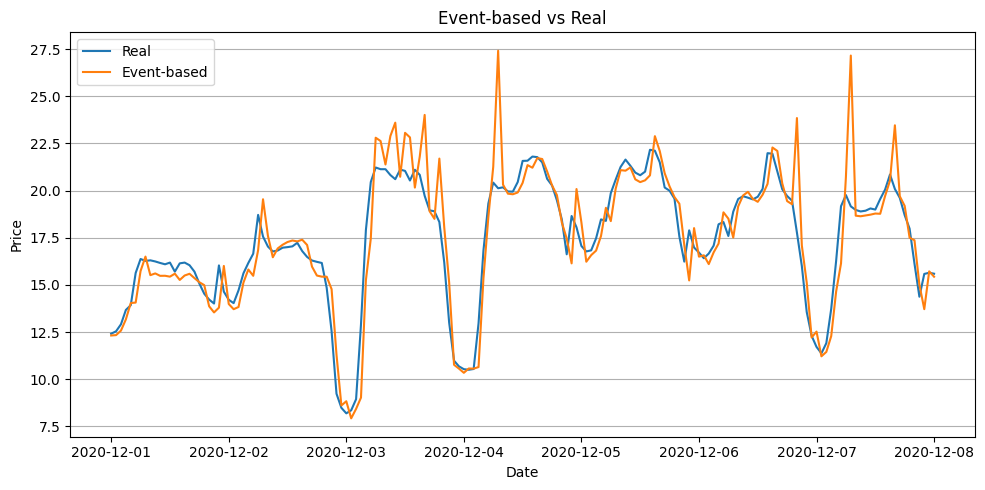

In [78]:
# ============================================================
# 11. REAL VS PREDICTED PLOT
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(results.index, results["real_price"], label="Real")
plt.plot(results.index, results["predicted_price"], label="Event-based")

plt.title("Event-based vs Real")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, axis="y")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()